In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('winequalityN.csv')
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [2]:
print("Shape:", df.shape)
print(df['type'].value_counts())
print(df.isnull().sum())

Shape: (6497, 13)
type
white    4898
red      1599
Name: count, dtype: int64
type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64


0
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


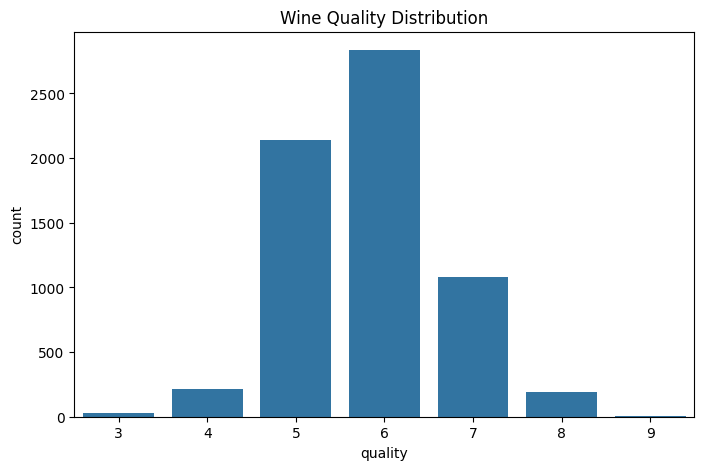

In [3]:
# Fill numeric nulls with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum().sum())  # should be 0 now

# Check quality class distribution
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title('Wine Quality Distribution')
plt.show()

In [4]:
def quality_bin(q):
    if q <= 5:
        return 'low'
    elif q == 6:
        return 'medium'
    else:
        return 'high'

df['quality_label'] = df['quality'].apply(quality_bin)
print(df['quality_label'].value_counts())

quality_label
medium    2836
low       2384
high      1277
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['quality', 'quality_label', 'type'])
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (5197, 11)
Test shape: (1300, 11)


In [7]:
# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

# SGD Classifier
sgd = SGDClassifier(random_state=42, max_iter=1000)
sgd.fit(X_train_scaled, y_train)
sgd_pred = sgd.predict(X_test_scaled)

# SVC
svc = SVC(random_state=42)
svc.fit(X_train_scaled, y_train)
svc_pred = svc.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

Random Forest Accuracy: 0.7315384615384616
SGD Accuracy: 0.53
SVC Accuracy: 0.6169230769230769


              precision    recall  f1-score   support

        high       0.77      0.61      0.68       256
         low       0.78      0.76      0.77       477
      medium       0.68      0.77      0.72       567

    accuracy                           0.73      1300
   macro avg       0.75      0.71      0.72      1300
weighted avg       0.74      0.73      0.73      1300



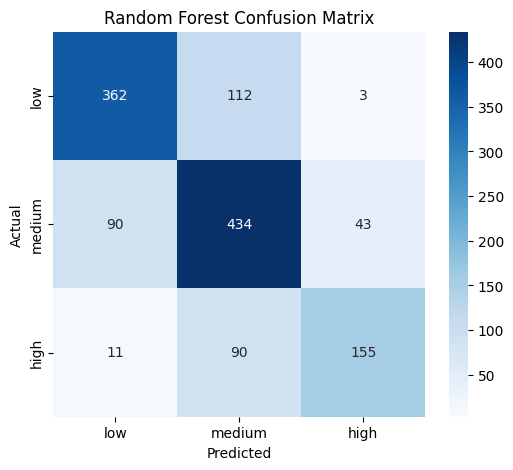

In [8]:
print(classification_report(y_test, rf_pred))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, rf_pred, labels=['low','medium','high']),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['low','medium','high'], yticklabels=['low','medium','high'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

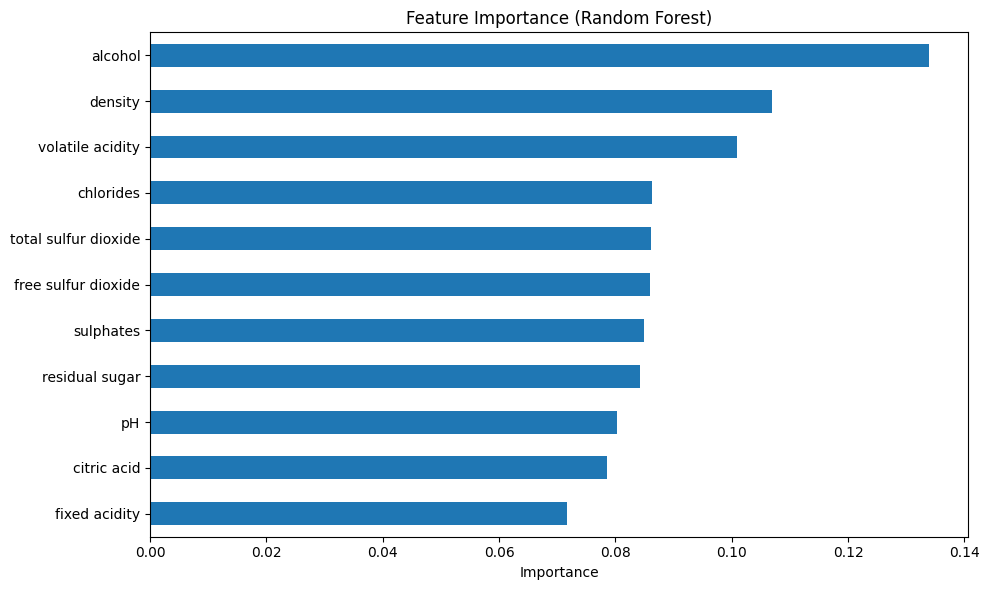

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, sgd_pred), accuracy_score(y_test, svc_pred)]
})
print(comparison)

           Model  Accuracy
0  Random Forest  0.731538
1            SGD  0.530000
2            SVC  0.616923


# **Conclusion:**
Random Forest was the most suitable model for this task (73% accuracy), significantly outperforming SGD (53%) and SVC (62%) it handles the non-linear relationships between chemical properties and wine quality far better than linear-based approaches. Alcohol content emerged as the single strongest predictor of quality, followed by density and volatile acidity. For deployment, Random Forest's higher accuracy and balanced precision/recall across classes make it the clear choice, though the "high" quality class remains harder to detect due to its smaller sample size collecting more high-quality wine samples would likely improve performance further.